In [ ]:
from pathlib import Path

SOURCE_VIDEO_PATH = "/workspace/Basketball-player-tracking/data/Q1_part1_game2.mp4"
#SOURCE_VIDEO_PATH = "/workspace/Basketball-player-tracking/data/1st_possession_knicks_court.mp4"
#SOURCE_VIDEO_PATH = "/workspace/Basketball-player-tracking/data/1_possession_game2_celtics_court.mp4"
DURATION_S = 30

In [2]:
import os
os.environ["CORE_MODEL_SAM_ENABLED"] = "False"
os.environ["CORE_MODEL_YOLO_WORLD_ENABLED"] = "False"
os.environ["CORE_MODEL_GAZE_ENABLED"] = "False"

In [3]:
import numpy as np
import pandas as pd
import supervision as sv
from inference.models.utils import get_model
from tqdm.auto import tqdm
from sports import (
    clean_paths,
    ConsecutiveValueTracker,
    TeamClassifier,
    MeasurementUnit,
    ViewTransformer
)
from sports.basketball import (
    CourtConfiguration,
    League,
    draw_court,
    draw_points_on_court,
    draw_paths_on_court,
    draw_made_and_miss_on_court,
    ShotEventTracker
)

[08/26/26 17:39:33] WARNING  Your inference package version 1.3.7 is out of date! Please upgrade to  ]8;id=14515411;file:///workspace/Basketball-player-tracking/.venv/lib/python3.11/site-packages/inference/core/__init__.py\__init__.py]8;;\:]8;id=14515412;file:///workspace/Basketball-player-tracking/.venv/lib/python3.11/site-packages/inference/core/__init__.py#50\50]8;;\
                             version 1.5.0 of inference for the latest features and bug fixes by                   
                             running `pip install --upgrade inference`.                                            

[transformers] `DepthProImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `DepthProImageProcessor` instead.


In [4]:
PLAYER_DETECTION_MODEL_ID = "basketball-player-detection-3-ycjdo/13"
PLAYER_DETECTION_MODEL_CONFIDENCE = 0.4
PLAYER_DETECTION_MODEL_IOU_THRESHOLD = 0.9
PLAYER_DETECTION_MODEL = get_model(model_id=PLAYER_DETECTION_MODEL_ID)

KEYPOINT_DETECTION_MODEL_ID = "basketball-court-detection-2/14"
KEYPOINT_DETECTION_MODEL_CONFIDENCE = 0.3
KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE = 0.5
KEYPOINT_DETECTION_MODEL = get_model(model_id=KEYPOINT_DETECTION_MODEL_ID)
KEYPOINT_COLOR = sv.Color.from_hex('#FF1493')

COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

In [5]:
PLAYER_JUMP_SHOT_CLASS_ID = 5
FRAME_IDX = 730
i=0

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=FRAME_IDX-5, iterative_seek=True)

for frame in frame_generator:
    frame = next(frame_generator)
    i += 1
    if i > 10:
        break

    result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
    detections = sv.Detections.from_inference(result)
    detections = detections[detections.class_id == PLAYER_JUMP_SHOT_CLASS_ID]

    annotated_frame = frame.copy()
    annotated_frame = box_annotator.annotate(
        scene=annotated_frame,
        detections=detections)
    annotated_frame = label_annotator.annotate(
        scene=annotated_frame,
        detections=detections)

    # sv.plot_image(annotated_frame)

Selected RF-DETR preprocessor implementation=base max_workers=4


PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/


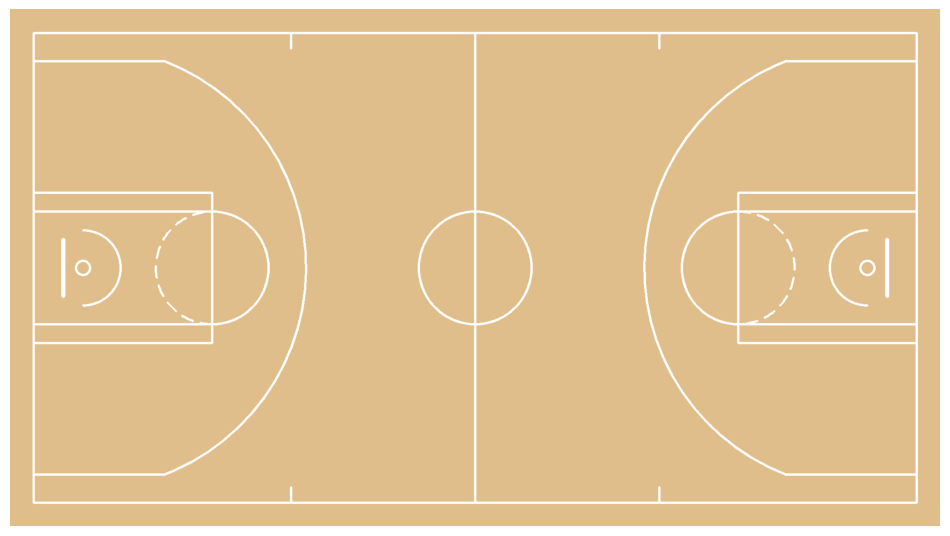

In [6]:
config = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=FRAME_IDX, iterative_seek=True)
frame = next(frame_generator)

# we use a RF-DETR model to detect players

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[detections.class_id == PLAYER_JUMP_SHOT_CLASS_ID]

# we use a keypoint model to detect court landmarks.
# Infer returns only detected landmarks (e.g. 13), while the court has 33
# vertices — match them by class_id, not a boolean mask.

result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE)[0]
key_points = sv.KeyPoints.from_inference(result)
payload = result.dict(exclude_none=True, by_alias=True) if hasattr(result, "dict") else result
raw_keypoints = (payload.get("predictions") or [{}])[0].get("keypoints") or []
vertices = np.asarray(config.vertices, dtype=float)

frame_landmarks, vertex_ids = [], []
for i, kp in enumerate(raw_keypoints):
    if float(kp.get("confidence", 0.0)) <= KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE:
        continue
    class_id = kp.get("class_id")
    if class_id is None:
        class_id = i if len(raw_keypoints) == len(vertices) else None
    else:
        class_id = int(class_id)
    if class_id is None or class_id < 0 or class_id >= len(vertices):
        continue
    vertex_ids.append(class_id)
    frame_landmarks.append([float(kp["x"]), float(kp["y"])])

if len(vertex_ids) >= 4:

    # we calculate homography matrix

    frame_landmarks = np.asarray(frame_landmarks, dtype=float)
    court_landmarks = vertices[np.asarray(vertex_ids, dtype=int)]

    frame_to_court_transformer = ViewTransformer(
        source=frame_landmarks,
        target=court_landmarks,
    )

    frame_xy = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)

    # transform video frame coordinates into court coordinates

    court_xy = frame_to_court_transformer.transform_points(points=frame_xy)

    court = draw_made_and_miss_on_court(
        config=config,
        miss_xy=court_xy,
        miss_color = sv.Color.from_hex("#850101"),
        miss_size= 10,
        made_size=25,
        made_color=sv.Color.from_hex("#007A33"),
        made_thickness=6,
        miss_thickness=6,
        line_thickness=4
    )

    sv.plot_image(court)


In [12]:
BALL_IN_BASKET_CLASS_ID = 1
JUMP_SHOT_CLASS_ID = 5
LAYUP_DUNK_CLASS_ID = 6

config = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)
vertex_annotator = sv.VertexAnnotator(color=KEYPOINT_COLOR, radius=8)
box_annotator = sv.BoxAnnotator(color=COLOR, thickness=1)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, stride=3)
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

shot_event_tracker = ShotEventTracker(
    reset_time_frames=int(video_info.fps * 1.7),
    minimum_frames_between_starts=int(video_info.fps * 0.5),
    cooldown_frames_after_made=int(video_info.fps * 0.5),
)


def map_shooter_to_court(frame, detections):
    """Detect court landmarks and map shooter feet into court coordinates."""
    result = KEYPOINT_DETECTION_MODEL.infer(
        frame, confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE
    )[0]
    key_points = sv.KeyPoints.from_inference(result)
    payload = result.dict(exclude_none=True, by_alias=True) if hasattr(result, "dict") else result
    raw_keypoints = (payload.get("predictions") or [{}])[0].get("keypoints") or []
    vertices = np.asarray(config.vertices, dtype=float)

    frame_landmarks, vertex_ids = [], []
    for i, kp in enumerate(raw_keypoints):
        if float(kp.get("confidence", 0.0)) <= KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE:
            continue
        class_id = kp.get("class_id")
        if class_id is None:
            class_id = i if len(raw_keypoints) == len(vertices) else None
        else:
            class_id = int(class_id)
        if class_id is None or class_id < 0 or class_id >= len(vertices):
            continue
        vertex_ids.append(class_id)
        frame_landmarks.append([float(kp["x"]), float(kp["y"])])

    if len(vertex_ids) < 4 or len(detections) == 0:
        return key_points, None

    frame_to_court_transformer = ViewTransformer(
        source=np.asarray(frame_landmarks, dtype=float),
        target=vertices[np.asarray(vertex_ids, dtype=int)],
    )
    frame_xy = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)
    court_xy = frame_to_court_transformer.transform_points(points=frame_xy)
    return key_points, court_xy


pending_shot = None
shots = []

for frame_index, frame in enumerate(tqdm(frame_generator, desc="shot events")):

    # we use a RF-DETR model to detect jump shot, layup, dunk and ball in basket

    result = PLAYER_DETECTION_MODEL.infer(
        frame,
        confidence=PLAYER_DETECTION_MODEL_CONFIDENCE,
        iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD,
    )[0]
    detections = sv.Detections.from_inference(result)

    jump_dets = detections[detections.class_id == JUMP_SHOT_CLASS_ID]
    layup_dets = detections[detections.class_id == LAYUP_DUNK_CLASS_ID]
    has_jump_shot = len(jump_dets) > 0
    has_layup_dunk = len(layup_dets) > 0
    has_ball_in_basket = len(detections[detections.class_id == BALL_IN_BASKET_CLASS_ID]) > 0

    events = shot_event_tracker.update(
        frame_index=frame_index,
        has_jump_shot=has_jump_shot,
        has_layup_dunk=has_layup_dunk,
        has_ball_in_basket=has_ball_in_basket,
    )

    if not events:
        continue

    print(events)

    for event in events:
        kind = event["event"]

        if kind == "START":
            event_dets = jump_dets if event["type"] == "JUMP" else layup_dets
            key_points, court_xy = map_shooter_to_court(frame, event_dets)

            court_x, court_y = np.nan, np.nan
            if court_xy is not None and len(court_xy) > 0:
                court_x, court_y = float(court_xy[0][0]), float(court_xy[0][1])

            pending_shot = {
                "start_frame": int(event["frame"]),
                "end_frame": None,
                "outcome": None,
                "shot_type": event["type"].lower(),
                "court_x": court_x,
                "court_y": court_y,
            }

            annotated_frame = frame.copy()
            if len(key_points) > 0:
                annotated_frame = vertex_annotator.annotate(
                    scene=annotated_frame,
                    key_points=key_points,
                )
            annotated_frame = box_annotator.annotate(
                scene=annotated_frame,
                detections=event_dets,
            )
            annotated_frame = label_annotator.annotate(
                scene=annotated_frame,
                detections=event_dets,
            )
            if np.isfinite(court_x) and np.isfinite(court_y):
                print(
                    f"START {event['type']} frame={event['frame']} "
                    f"court=({court_x:.1f}, {court_y:.1f})"
                )
            else:
                print(f"START {event['type']} frame={event['frame']} court=unmapped")
            sv.plot_image(annotated_frame)

        elif kind in {"MADE", "MISSED"}:
            row = pending_shot if pending_shot is not None else {
                "start_frame": int(event["frame"]),
                "end_frame": None,
                "outcome": None,
                "shot_type": event["type"].lower(),
                "court_x": np.nan,
                "court_y": np.nan,
            }
            row["end_frame"] = int(event["frame"])
            row["outcome"] = kind.lower()
            shots.append(row)
            pending_shot = None

if pending_shot is not None:
    pending_shot["end_frame"] = int(frame_index)
    pending_shot["outcome"] = "missed"
    shots.append(pending_shot)

shots_df = pd.DataFrame(
    shots,
    columns=["start_frame", "end_frame", "outcome", "shot_type", "court_x", "court_y"],
)
shots_df


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x1951f440] moov atom not found


Exception: Could not open video at /workspace/Basketball-player-tracking/data/Q1_part1_game2.mov

mapped made=1  mapped miss=0


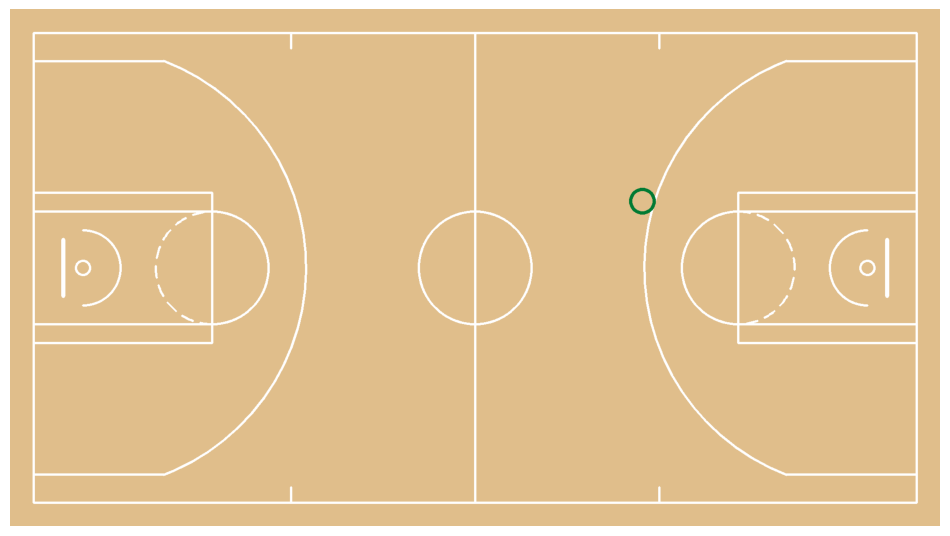

In [8]:
made_xy = shots_df.loc[shots_df["outcome"] == "made", ["court_x", "court_y"]].to_numpy(dtype=float)
miss_xy = shots_df.loc[shots_df["outcome"] == "missed", ["court_x", "court_y"]].to_numpy(dtype=float)

made_xy = made_xy[np.isfinite(made_xy).all(axis=1)] if len(made_xy) else made_xy
miss_xy = miss_xy[np.isfinite(miss_xy).all(axis=1)] if len(miss_xy) else miss_xy

court = draw_made_and_miss_on_court(
    config=config,
    made_xy=made_xy if len(made_xy) else None,
    miss_xy=miss_xy if len(miss_xy) else None,
    miss_color=sv.Color.from_hex("#850101"),
    made_color=sv.Color.from_hex("#007A33"),
    miss_size=10,
    made_size=25,
    made_thickness=6,
    miss_thickness=6,
    line_thickness=4,
)

print(f"mapped made={len(made_xy)}  mapped miss={len(miss_xy)}")
sv.plot_image(court)
